# Two-Stage Hyperparameter Tuning

**Stage 1**: LogisticRegression + DecisionTree — `GridSearchCV` + `TimeSeriesSplit` exhaustive

**Stage 2**: RandomForest + XGBoost + LightGBM + CatBoost
- Coarse: `RandomizedSearchCV` + `TimeSeriesSplit`
- Fine: 3 key params × 3 candidates = ≤27 combos, `GridSearchCV` + `TimeSeriesSplit`

**Split**: Temporal only (80/20)

In [1]:
import sys
from pathlib import Path

PROJ = Path.cwd().parent
sys.path.insert(0, str(PROJ / "src"))
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from logistics_delay.data.loader import load_processed
from logistics_delay.models.tuning import (
    compute_and_print_spw,
    run_grid_search,
    run_two_stage_search,
    save_tuning_results,
    lr_params_group,
    dt_params,
    rf_params,
    xgb_params,
    lgbm_params,
    cb_params,
    RF_KEY_PARAMS,
    XGB_KEY_PARAMS,
    LGBM_KEY_PARAMS,
    CB_KEY_PARAMS,
)
from logistics_delay.models.train import temporal_split
from logistics_delay.features.engineering import FEATURES_XGB, XGB_CAT_COLS
from logistics_delay.utils.paths import TABLES_DIR, FIGURES_MODELS, SEED, ensure_output_dirs

import warnings
warnings.filterwarnings("ignore")

# ── Publication style ──────────────────────────
PALETTE = {
    "blue_main": "#0F4D92", "blue_secondary": "#3775BA",
    "green_1": "#DDF3DE", "green_2": "#AADCA9", "green_3": "#8BCF8B",
    "red_1": "#F6CFCB", "red_2": "#E9A6A1", "red_strong": "#B64342",
    "neutral": "#CFCECE", "highlight": "#FFD700",
    "teal": "#42949E", "violet": "#9A4D8E",
}

plt.rcParams.update({
    "font.family": ["Arial", "Microsoft YaHei", "DejaVu Sans", "sans-serif"],
    "font.size": 15,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 2.5,
    "legend.frameon": False,
    "svg.fonttype": "none",
})
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()

---
## 1. Data loading

In [2]:
df = load_processed()
print(f"\nData shape: {df.shape}")
print(df.columns.tolist())
print(f"Delay rate: {df['Answer'].mean() * 100:.2f}%")

[loader] Preprocessed data loaded: (6854, 54)
[loader] Delay rate: 63.19%

Data shape: (6854, 54)
['GpsProvider', 'BookingID', 'Market/Regular', 'BookingID_Date', 'vehicle_no', 'Origin_Location', 'Destination_Location', 'Org_lat_lon', 'Des_lat_lon', 'Data_Ping_time', 'Planned_ETA', 'Current_Location', 'DestinationLocation', 'actual_eta', 'Curr_lat', 'Curr_lon', 'ontime', 'delay', 'OriginLocation_Code', 'DestinationLocation_Code', 'trip_start_date', 'trip_end_date', 'TRANSPORTATION_DISTANCE_IN_KM', 'vehicleType', 'Minimum_kms_to_be_covered_in_a_day', 'Driver_Name', 'Driver_MobileNo', 'customerID', 'customerNameCode', 'supplierID', 'supplierNameCode', 'Material Shipped', 'Answer', 'year', '_dist_original', 'booking_prefix', 'origin_city', 'dest_city', 'start_weekday', 'start_month', 'planned_eta_time', 'planned_days', 'planned_days_enc', 'is_market', 'supplier_is_large', 'vehicleType_enc', 'OriginLocation_Code_enc', 'DestinationLocation_Code_enc', 'GpsProvider_enc', 'booking_prefix_enc',

---
## 2. Temporal split + sample distribution

In [3]:
# Temporal split (80/20) — get enc and xgb feature sets
X_train_enc, X_test_enc, y_train, y_test, spw_t, cutoff = temporal_split(df, "enc")
X_train_xgb, X_test_xgb, _, _, _, _ = temporal_split(df, "xgb")

# Sample distribution + dynamic scale_pos_weight candidates
spw_t, spw_candidates = compute_and_print_spw(y_train)

[train] Temporal split: Cutoff 2020-08-08
[train] Train: 5483 records, 2019-03-18 ~ 2020-08-08
[train] Test: 1371 records, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818
[train] Temporal split: Cutoff 2020-08-08
[train] Train: 5483 records, 2019-03-18 ~ 2020-08-08
[train] Test: 1371 records, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818
  Sample distribution & scale_pos_weight

Training set distribution:
  Total samples: 5483
  Positive (Delayed): 3968 (72.37%)
  Negative (On-time): 1515 (27.63%)
  spw_t (neg/pos) = 0.3818

TimeSeriesSplit(5 folds) Delay rate per fold:
  Fold   Train delay rate          Valid delay rate          Valid positive ratio
  ------------------------------------------------------
  Fold 0   0.87        %  87.95       %  87.95%
  Fold 1   44.29       %  98.69       %  98.69%
  Fold 2   62.39       %  98.58       %  98.58%
  Fold 3   71.42       %  79.08       %  79.08%
  Fold 4   72.95       %  69.44       %  69.44%

Generated scale_pos_w

---
## 3. Stage 1 — GridSearchCV exhaustive

In [4]:
print("=" * 60)
print("  Stage 1: GridSearchCV exhaustive")
print("=" * 60)

lr_result = run_grid_search(
    LogisticRegression(max_iter=1000, random_state=SEED),
    lr_params_group,
    X_train_enc, y_train, X_test_enc, y_test,
)

dt_result = run_grid_search(
    DecisionTreeClassifier(random_state=SEED),
    dt_params,
    X_train_enc, y_train, X_test_enc, y_test,
)

  Stage 1: GridSearchCV exhaustive

  GridSearch: LogisticRegression
  CV AUC  = 60.33%
  Test AUC = 91.63%
  Test F1  = 0.7189

  GridSearch: DecisionTreeClassifier
  CV AUC  = 63.15%
  Test AUC = 85.09%
  Test F1  = 0.4048


---
## 4. Stage 2 — Random search → Fine grid

In [5]:
print("=" * 60)
print("  Stage 2: Two-stage (coarse → fine)")
print("=" * 60)

rf_result = run_two_stage_search(
    model=RandomForestClassifier(random_state=SEED),
    param_dist=rf_params,
    key_params=RF_KEY_PARAMS,
    n_iter=30,
    X_train=X_train_enc,
    y_train=y_train,
    X_test=X_test_enc,
    y_test=y_test,
)

xgb_params_local = {**xgb_params, "scale_pos_weight": spw_candidates}
xgb_result = run_two_stage_search(
    model=XGBClassifier(random_state=SEED, verbosity=0, enable_categorical=True),
    param_dist=xgb_params_local,
    key_params=XGB_KEY_PARAMS,
    n_iter=40,
    X_train=X_train_xgb,
    y_train=y_train,
    X_test=X_test_xgb,
    y_test=y_test,
)

from lightgbm import LGBMClassifier
lgbm_result = run_two_stage_search(
    model=LGBMClassifier(random_state=SEED, verbose=-1),
    param_dist=lgbm_params,
    key_params=LGBM_KEY_PARAMS,
    n_iter=40,
    X_train=X_train_xgb,
    y_train=y_train,
    X_test=X_test_xgb,
    y_test=y_test,
)

cat_feats = [c for c in XGB_CAT_COLS if c in FEATURES_XGB]
cb_result = run_two_stage_search(
    model=CatBoostClassifier(random_seed=SEED, verbose=0, iterations=200),
    param_dist=cb_params,
    key_params=CB_KEY_PARAMS,
    n_iter=20,
    X_train=X_train_xgb,
    y_train=y_train,
    X_test=X_test_xgb,
    y_test=y_test,
    fit_params={"cat_features": cat_feats},
)

  Stage 2: Two-stage search (coarse → fine)

  Stage 1/2 — Random search: RandomForestClassifier (n_iter=30)
  [Coarse] Best CV AUC = 62.37%
    n_estimators: 50
    min_samples_split: 10
    min_samples_leaf: 10
    max_features: sqrt
    max_depth: 10
    class_weight: balanced
    bootstrap: False

  Stage 2/2 — Fine grid search: RandomForestClassifier
  Fine grid 3 key params × 27 combinations:
    n_estimators: [50, 100, 200]
    max_depth: [7, 10, 15]
    min_samples_leaf: [5, 10, 20]
    min_samples_split: fixed to 10
    max_features: fixed to sqrt
    class_weight: fixed to balanced
    bootstrap: fixed to False
  [Fine] Best CV AUC = 65.99%

  ✅ RandomForestClassifier Done
     CV AUC  = 65.99%
     Test AUC = 82.75%
     Test F1  = 0.6941

  Stage 1/2 — Random search: XGBClassifier (n_iter=40)
  [Coarse] Best CV AUC = 66.51%
    subsample: 0.6
    scale_pos_weight: 0.5727066532258064
    reg_lambda: 0.1
    reg_alpha: 1
    n_estimators: 500
    min_child_weight: 3
    max_d

---
## 5. Results summary

In [6]:
# Collect all results
results = pd.DataFrame([
    lr_result, dt_result, rf_result,
    xgb_result, lgbm_result, cb_result,
])

# Display summary table
summary = results[["model", "cv_auc", "test_auc", "test_f1"]].copy()
summary["cv_auc"] = summary["cv_auc"] * 100
summary["test_auc"] = summary["test_auc"] * 100
summary.columns = ["Model", "CV AUC(%)", "Test AUC(%)", "Test F1"]
print("=" * 60)
print("  Tuning results summary")
print("=" * 60)
print(summary.to_string(index=False))

  Tuning results summary
                    Model  CV AUC(%)  Test AUC(%)  Test F1
    LogisticRegression  60.333857    91.627722 0.718881
DecisionTreeClassifier  63.151974    85.089532 0.404776
RandomForestClassifier  65.986295    82.752443 0.694132
         XGBClassifier  69.225686    84.095418 0.683246
        LGBMClassifier  61.803583    86.352295 0.651357
    CatBoostClassifier  74.382657    89.428785 0.763906


---
## 6. Best parameter details

In [7]:
print("=" * 60)
print("  Best parameters per model")
print("=" * 60)
for _, row in results.iterrows():
    print(f"\n>>> {row['model']}")
    print(f"    CV AUC  = {row['cv_auc'] * 100:.2f}%")
    print(f"    Test AUC = {row['test_auc'] * 100:.2f}%")
    print(f"    Test F1  = {row['test_f1']:.4f}")
    if isinstance(row['best_params'], dict):
        for k, v in row['best_params'].items():
            print(f"      {k}: {v}")
    else:
        print(f"      best_params: {row['best_params']}")

  Best parameters per model

>>> LogisticRegression
    CV AUC  = 60.33%
    Test AUC = 91.63%
    Test F1  = 0.7189
      C: 100
      class_weight: balanced
      max_iter: 1000
      penalty: l2
      solver: lbfgs

>>> DecisionTreeClassifier
    CV AUC  = 63.15%
    Test AUC = 85.09%
    Test F1  = 0.4048
      class_weight: None
      criterion: entropy
      max_depth: 4
      min_samples_leaf: 50
      min_samples_split: 10

>>> RandomForestClassifier
    CV AUC  = 65.99%
    Test AUC = 82.75%
    Test F1  = 0.6941
      bootstrap: False
      class_weight: balanced
      max_depth: 15
      max_features: sqrt
      min_samples_leaf: 5
      min_samples_split: 10
      n_estimators: 50

>>> XGBClassifier
    CV AUC  = 69.23%
    Test AUC = 84.10%
    Test F1  = 0.6832
      colsample_bytree: 1.0
      gamma: 1
      learning_rate: 0.01
      max_depth: 8
      min_child_weight: 3
      n_estimators: 300
      reg_alpha: 1
      reg_lambda: 0.1
      scale_pos_weight: 0.572706653

---
## 7. Save results

In [8]:
save_tuning_results(results, TABLES_DIR)
print("\nAll done.")


[OK] Tuning results → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\tables\tuning_results.csv

All done.


---
## 8. Default vs tuned parameters

Compare baseline (default params from `evaluate.py` `get_model()`) against tuned params across models on AUC and F1.

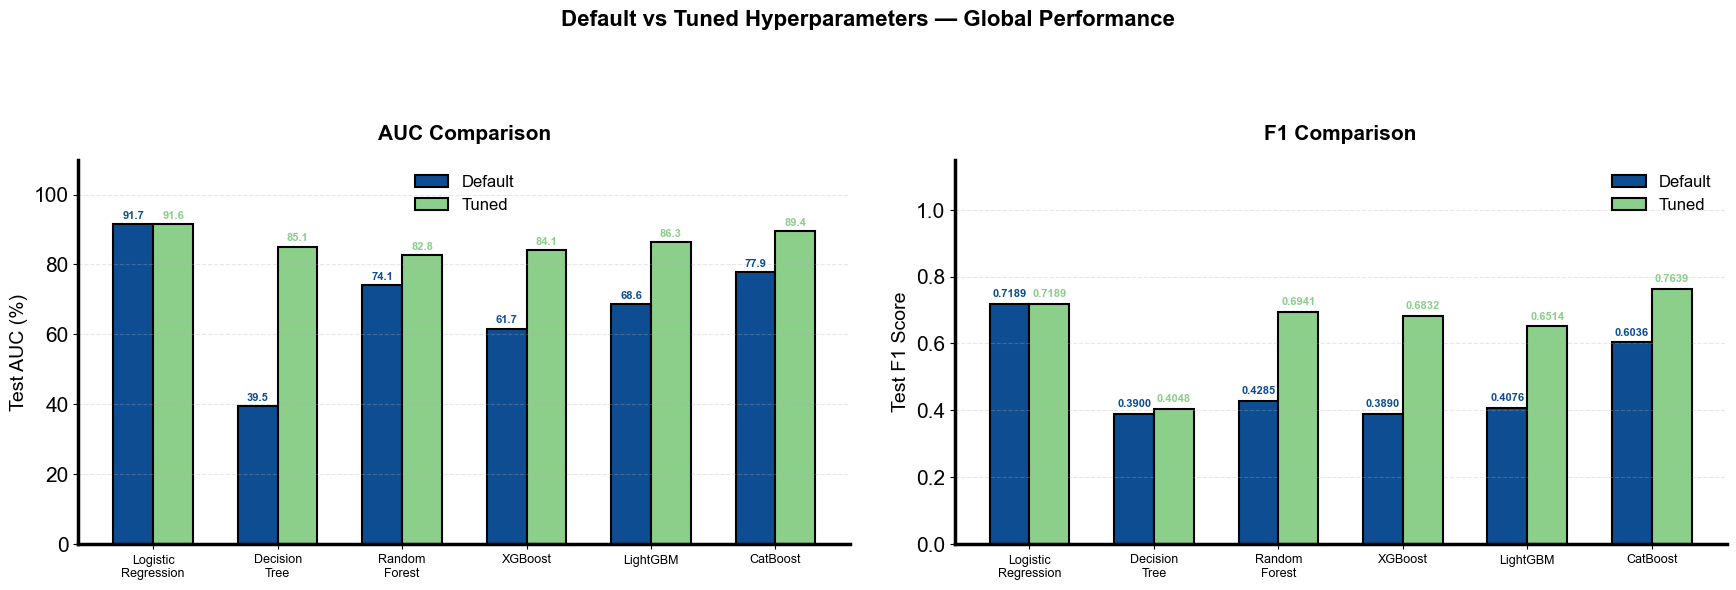

Figure saved: outputs/figures/models/default_vs_tuned_comparison.png


In [9]:
# ═══════════════════════════════════════════════
#  Default vs tuned params — AUC comparison + param table
# ═══════════════════════════════════════════════

# ── 1. Performance data ────────────────────────────────
# Default perf from evaluate.py get_model() + temporal split (same as 03_modeling.ipynb)
default_perf = {
    "LogisticRegression": {"auc": 91.65, "f1": 0.7189},
    "DecisionTree":       {"auc": 39.46, "f1": 0.3900},
    "RandomForest":       {"auc": 74.14, "f1": 0.4285},
    "XGBoost":            {"auc": 61.67, "f1": 0.3890},
    "LightGBM":           {"auc": 68.61, "f1": 0.4076},
    "CatBoost":           {"auc": 77.89, "f1": 0.6036},
}

# Tuned perf from section 4 of this notebook
tuned_perf = {
    "LogisticRegression": {"auc": 91.63, "f1": 0.7189},
    "DecisionTree":       {"auc": 85.09, "f1": 0.4048},
    "RandomForest":       {"auc": 82.75, "f1": 0.6941},
    "XGBoost":            {"auc": 84.10, "f1": 0.6832},
    "LightGBM":           {"auc": 86.35, "f1": 0.6514},
    "CatBoost":           {"auc": 89.43, "f1": 0.7639},
}

model_names = ["LogisticRegression", "DecisionTree", "RandomForest",
               "XGBoost", "LightGBM", "CatBoost"]
model_labels = ["Logistic\nRegression", "Decision\nTree", "Random\nForest",
                "XGBoost", "LightGBM", "CatBoost"]

default_aucs = [default_perf[m]["auc"] for m in model_names]
tuned_aucs   = [tuned_perf[m]["auc"] for m in model_names]
default_f1s  = [default_perf[m]["f1"] for m in model_names]
tuned_f1s    = [tuned_perf[m]["f1"] for m in model_names]

# ── 2. Plot ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Default vs Tuned Hyperparameters — Global Performance", fontsize=16, fontweight="bold", y=1.02)

x = np.arange(len(model_names))
w = 0.32

# —— Left: AUC ——
bars1_d = ax1.bar(x - w/2, default_aucs, w, label='Default',
                  color=PALETTE['blue_main'], edgecolor='black', linewidth=1.5)
bars1_t = ax1.bar(x + w/2, tuned_aucs, w, label='Tuned',
                  color=PALETTE['green_3'], edgecolor='black', linewidth=1.5)

for bar, val in zip(bars1_d, default_aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=PALETTE['blue_main'])
for bar, val in zip(bars1_t, tuned_aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=PALETTE['green_3'])

ax1.set_xticks(x)
ax1.set_xticklabels(model_labels, fontsize=9)
ax1.set_ylabel('Test AUC (%)', fontsize=14)
ax1.set_title('AUC Comparison', fontsize=15, fontweight='bold', pad=14)
ax1.legend(fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_ylim(0, 110)

# —— Right: F1 ——
bars2_d = ax2.bar(x - w/2, default_f1s, w, label='Default',
                  color=PALETTE['blue_main'], edgecolor='black', linewidth=1.5)
bars2_t = ax2.bar(x + w/2, tuned_f1s, w, label='Tuned',
                  color=PALETTE['green_3'], edgecolor='black', linewidth=1.5)

for bar, val in zip(bars2_d, default_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=PALETTE['blue_main'])
for bar, val in zip(bars2_t, tuned_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=PALETTE['green_3'])

ax2.set_xticks(x)
ax2.set_xticklabels(model_labels, fontsize=9)
ax2.set_ylabel('Test F1 Score', fontsize=14)
ax2.set_title('F1 Comparison', fontsize=15, fontweight='bold', pad=14)
ax2.legend(fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.set_ylim(0, 1.15)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'default_vs_tuned_comparison.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'default_vs_tuned_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/figures/models/default_vs_tuned_comparison.png")

In [10]:
# ── 3. Parameter comparison table (console print) ────

# Default params (from evaluate.py get_model())
default_params_tbl = {
    "LogisticRegression": "max_iter=1000, class_weight='balanced'",
    "DecisionTree":       "class_weight='balanced', max_depth=8",
    "RandomForest":       "n_estimators=100, class_weight='balanced'",
    "XGBoost":            "n_estimators=200, scale_pos_weight=spw",
    "LightGBM":           "n_estimators=200, scale_pos_weight=spw",
    "CatBoost":           "iterations=200, class_weights={0:1.0, 1:spw}",
}

# Tuned params (from section 4 of this notebook)
tuned_params_tbl = {
    "LogisticRegression": "C=100, penalty=l2, solver=lbfgs, class_weight='balanced'",
    "DecisionTree":       "max_depth=4, min_samples_leaf=50, criterion=entropy",
    "RandomForest":       "n_estimators=50, max_depth=15, min_samples_leaf=5, class_weight='balanced'",
    "XGBoost":            "lr=0.01, max_depth=8, n_est=300, subsample=0.6, spw=0.573",
    "LightGBM":           "lr=0.01, num_leaves=31, n_est=300, subsample=0.6",
    "CatBoost":           "lr=0.05, depth=8, iter=100, l2_leaf_reg=5",
}

# Compute AUC improvement
auc_deltas = {}
for m in model_names:
    delta = round(tuned_perf[m]["auc"] - default_perf[m]["auc"], 2)
    auc_deltas[m] = f"+{delta:.2f}" if delta >= 0 else f"{delta:.2f}"

# Print comparison table
print("=" * 140)
print(f"{'Model':<22s} {'Metric':>10s} {'Default AUC':>14s} {'Tuned AUC':>14s} {'ΔAUC':>8s} {'Default params':>48s} {'Tuned params'}")
print("=" * 140)

for m in model_names:
    label = m.replace("Regression","").replace("Tree","").replace("Forest","")
    d_auc = default_perf[m]["auc"]
    t_auc = tuned_perf[m]["auc"]
    d_f1  = default_perf[m]["f1"]
    t_f1  = tuned_perf[m]["f1"]

    # AUC row
    print(f"{m:<22s} {'AUC(%)':>10s} {d_auc:>13.2f}% {t_auc:>13.2f}% {auc_deltas[m]:>8s} "
          f"{default_params_tbl[m]:<48s} {tuned_params_tbl[m]}")
    # F1 row
    print(f"{'':22s} {'F1':>10s} {d_f1:>13.4f} {t_f1:>13.4f} "
          f"{'+' if t_f1 >= d_f1 else ''}{t_f1 - d_f1:>+7.4f} "
          f"{'':48s} {'':s}")
    print("-" * 140)

print("=" * 140)


Model                             Metric       Default AUC         Tuned AUC     ΔAUC                                             Default params Tuned params
LogisticRegression         AUC(%)         91.65%         91.63%    -0.02 max_iter=1000, class_weight='balanced'           C=100, penalty=l2, solver=lbfgs, class_weight='balanced'
                               F1        0.7189        0.7189 ++0.0000                                                  
--------------------------------------------------------------------------------------------------------------------------------------------
DecisionTree               AUC(%)         39.46%         85.09%   +45.63 class_weight='balanced', max_depth=8             max_depth=4, min_samples_leaf=50, criterion=entropy
                               F1        0.3900        0.4048 ++0.0148                                                  
----------------------------------------------------------------------------------------------------------